In [1]:
questionnaire = {
    "time_horizon": {
        "question": "How many years until you need this money?",
        "options": {
            "Less than 3 years": 1,
            "3-7 years": 2,
            "8-15 years": 3,
            "More than 15 years": 4
        }
    },
    "reaction_to_loss": {
        "question": "If your portfolio dropped 20% in a year, what would you do?",
        "options": {
            "Sell everything to stop the loss": 1,
            "Sell some to reduce risk": 2,
            "Do nothing and wait it out": 3,
            "Buy more while prices are low": 4
        }
    },
    "income_stability": {
        "question": "How stable is your income?",
        "options": {
            "Unstable / variable": 1,
            "Somewhat stable": 2,
            "Stable": 3,
            "Very stable (e.g., tenured, pension)": 4
        }
    },
    "experience": {
        "question": "How experienced are you with investing?",
        "options": {
            "No experience": 1,
            "Some experience": 2,
            "Experienced": 3,
            "Very experienced": 4
        }
    },
    "primary_goal": {
        "question": "What matters most to you?",
        "options": {
            "Preserving what I have": 1,
            "Steady, modest growth": 2,
            "Meaningful growth, some ups and downs are fine": 3,
            "Maximum growth, comfortable with big swings": 4
        }
    },
    "emergency_savings": {
        "question": "Do you have emergency savings outside this portfolio?",
        "options": {
            "No emergency savings": 1,
            "Less than 3 months of expenses": 2,
            "3-6 months of expenses": 3,
            "More than 6 months of expenses": 4
        }
    }
}

In [2]:
def score_client(answers):
    total_score = 0
    for question_key, answer in answers.items():
        points = questionnaire[question_key]["options"][answer]
        total_score += points
    return total_score

In [3]:
def classify_risk(score):
    if score <= 12:
        return "Conservative"
    elif score <= 18:
        return "Moderate"
    else:
        return "Aggressive"

In [4]:
sample_client = {
    "time_horizon": "8-15 years",
    "reaction_to_loss": "Do nothing and wait it out",
    "income_stability": "Stable",
    "experience": "Some experience",
    "primary_goal": "Meaningful growth, some ups and downs are fine",
    "emergency_savings": "3-6 months of expenses"
}

score = score_client(sample_client)
risk_category = classify_risk(score)

print(f"Total score: {score}")
print(f"Risk category: {risk_category}")

Total score: 17
Risk category: Moderate


In [5]:
import pandas as pd
sample_clients = {
    "Client A": {
        "time_horizon": "Less than 3 years",
        "reaction_to_loss": "Sell everything to stop the loss",
        "income_stability": "Unstable / variable",
        "experience": "No experience",
        "primary_goal": "Preserving what I have",
        "emergency_savings": "No emergency savings"
    },
    "Client B": {
        "time_horizon": "3-7 years",
        "reaction_to_loss": "Sell some to reduce risk",
        "income_stability": "Somewhat stable",
        "experience": "Some experience",
        "primary_goal": "Steady, modest growth",
        "emergency_savings": "Less than 3 months of expenses"
    },
    "Client C": {
        "time_horizon": "8-15 years",
        "reaction_to_loss": "Do nothing and wait it out",
        "income_stability": "Stable",
        "experience": "Some experience",
        "primary_goal": "Meaningful growth, some ups and downs are fine",
        "emergency_savings": "3-6 months of expenses"
    },
    "Client D": {
        "time_horizon": "More than 15 years",
        "reaction_to_loss": "Buy more while prices are low",
        "income_stability": "Very stable (e.g., tenured, pension)",
        "experience": "Very experienced",
        "primary_goal": "Maximum growth, comfortable with big swings",
        "emergency_savings": "More than 6 months of expenses"
    },
    "Client E": {
        "time_horizon": "8-15 years",
        "reaction_to_loss": "Sell some to reduce risk",
        "income_stability": "Stable",
        "experience": "No experience",
        "primary_goal": "Steady, modest growth",
        "emergency_savings": "3-6 months of expenses"
    }
}

results = []
for name, answers in sample_clients.items():
    score = score_client(answers)
    category = classify_risk(score)
    results.append({"Client": name, "Score": score, "Risk Category": category})

results_df = pd.DataFrame(results)
results_df

,Client,Score,Risk Category
0,Client A,6,Conservative
1,Client B,12,Conservative
2,Client C,17,Moderate
3,Client D,24,Aggressive
4,Client E,14,Moderate


In [6]:
allocation_map = {
    "Conservative": {"Stocks": 0.30, "Bonds": 0.60, "Cash/Gold": 0.10},
    "Moderate": {"Stocks": 0.60, "Bonds": 0.35, "Cash/Gold": 0.05},
    "Aggressive": {"Stocks": 0.85, "Bonds": 0.10, "Cash/Gold": 0.05}
}
results_df["Stocks %"] = results_df["Risk Category"].apply(lambda cat: allocation_map[cat]["Stocks"] * 100)
results_df["Bonds %"] = results_df["Risk Category"].apply(lambda cat: allocation_map[cat]["Bonds"] * 100)
results_df["Cash/Gold %"] = results_df["Risk Category"].apply(lambda cat: allocation_map[cat]["Cash/Gold"] * 100)

results_df

,Client,Score,Risk Category,Stocks %,Bonds %,Cash/Gold %
0,Client A,6,Conservative,30.0,60.0,10.0
1,Client B,12,Conservative,30.0,60.0,10.0
2,Client C,17,Moderate,60.0,35.0,5.0
3,Client D,24,Aggressive,85.0,10.0,5.0
4,Client E,14,Moderate,60.0,35.0,5.0


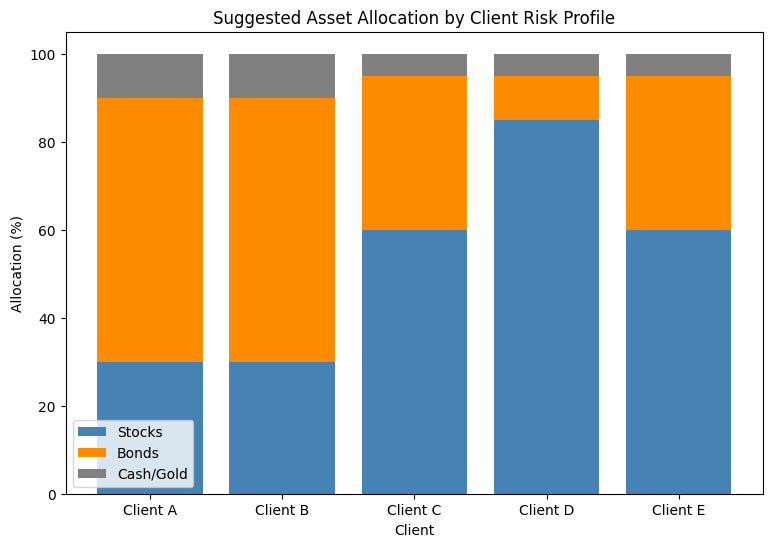

In [7]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(9, 6))

clients = results_df["Client"]
stocks = results_df["Stocks %"]
bonds = results_df["Bonds %"]
cash_gold = results_df["Cash/Gold %"]

ax.bar(clients, stocks, label="Stocks", color="steelblue")
ax.bar(clients, bonds, bottom=stocks, label="Bonds", color="darkorange")
ax.bar(clients, cash_gold, bottom=stocks + bonds, label="Cash/Gold", color="gray")

ax.set_title("Suggested Asset Allocation by Client Risk Profile")
ax.set_xlabel("Client")
ax.set_ylabel("Allocation (%)")
ax.legend()

plt.savefig('client_allocation_chart.png', dpi=150, bbox_inches='tight')
plt.show()